In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

C:\Users\ARATI\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
TRAIN_IMG_DIR = "oil_spill_dataset/train/images"
TRAIN_MASK_DIR = "oil_spill_dataset/train/masks"

VAL_IMG_DIR = "oil_spill_dataset/val/images"
VAL_MASK_DIR = "oil_spill_dataset/val/masks"

TEST_IMG_DIR = "oil_spill_dataset/test/images"
TEST_MASK_DIR = "oil_spill_dataset/test/masks"

In [3]:
def load_file_paths(image_dir, mask_dir):
    image_files = sorted([
        os.path.join(image_dir, f)
        for f in os.listdir(image_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    mask_files = sorted([
        os.path.join(mask_dir, f)
        for f in os.listdir(mask_dir)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ])

    return image_files, mask_files

In [4]:
train_imgs, train_masks = load_file_paths(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
val_imgs, val_masks     = load_file_paths(VAL_IMG_DIR, VAL_MASK_DIR)
test_imgs, test_masks   = load_file_paths(TEST_IMG_DIR, TEST_MASK_DIR)

In [5]:
#Using Losses and Metrics from Module 4
#Dice
#BCE+Dice
#IoU

from keras.saving import register_keras_serializable
from tensorflow.keras import backend as K

@register_keras_serializable()
def dice_coefficient(y_true, y_pred, smooth=1):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)
    intersection = K.sum(y_true * y_pred)
    return (2. * intersection + smooth) / (K.sum(y_true) + K.sum(y_pred) + smooth)

@register_keras_serializable()
def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

@register_keras_serializable()
def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

@register_keras_serializable()
def iou_score(y_true, y_pred, smooth=1):
    y_true = K.flatten(y_true)
    y_pred = K.flatten(y_pred)
    intersection = K.sum(y_true * y_pred)
    union = K.sum(y_true) + K.sum(y_pred) - intersection
    return (intersection + smooth) / (union + smooth)

In [6]:
model = load_model(
    "oil_spill_segmentation_unet.keras",
    custom_objects={
        "bce_dice_loss": bce_dice_loss,
        "dice_coefficient": dice_coefficient,
        "iou_score": iou_score
    }
)

model.summary()

C:\Users\ARATI\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 84 variables whereas the saved optimizer has 166 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "U-Net_SAR"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ re_lu[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ re_lu_2[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 62,096,516 (236.88 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

 Optimizer params: 31,042,371 (118.42 MB)

In [7]:
#Callbacks (Efficient and safe model training)
#EarlyStopping: Prevents overfitting
#ReduceLROnPlateau: Helps model converge better and improves performance
#ModelCheckPoint: Saves the best model based on validation Dice coefficient

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        "best_unet_model.keras",
        monitor="val_dice_coefficient",
        save_best_only=True,
        mode="max"
    )
]

In [8]:
#Test Set Evaluation

#Defining Test Paths
test_imgs = sorted([os.path.join(TEST_IMG_DIR, f) for f in os.listdir(TEST_IMG_DIR)])
test_masks = sorted([os.path.join(TEST_MASK_DIR, f) for f in os.listdir(TEST_MASK_DIR)])

print("Test images:", len(test_imgs))
print("Test masks:", len(test_masks))

Test images: 968
Test masks: 968


In [9]:
def data_generator(image_files, mask_files, batch_size, img_size):
    while True:
        for i in range(0, len(image_files), batch_size):

            batch_imgs = image_files[i:i+batch_size]
            batch_msks = mask_files[i:i+batch_size]

            if len(batch_imgs) < batch_size:
                continue

            images = np.zeros((batch_size, img_size, img_size, 1), dtype=np.float32)
            masks  = np.zeros((batch_size, img_size, img_size, 1), dtype=np.float32)

            for j, (img_path, mask_path) in enumerate(zip(batch_imgs, batch_msks)):
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                if img is None or mask is None:
                    continue

                img = cv2.resize(img, (img_size, img_size))
                mask = cv2.resize(mask, (img_size, img_size))

                images[j, ..., 0] = img / 255.0
                masks[j, ..., 0]  = (mask > 127).astype(np.float32)

            yield images, masks

In [10]:
IMG_SIZE=256
BATCH_SIZE=4

In [11]:
#Creating Test Generator
test_gen = data_generator(
    test_imgs,
    test_masks,
    BATCH_SIZE,
    256
)

In [12]:
#Evaluating on Unseen Test Data
test_loss, test_acc, test_dice, test_iou, test_prec, test_rec = model.evaluate(
    test_gen,
    steps=30,
    verbose=1
)

30/30 ━━━━━━━━━━━━━━━━━━━━ 61s 2s/step - accuracy: 0.9042 - dice_coefficient: 0.6045 - iou_score: 0.4420 - loss: 0.6632 - precision: 0.6762 - recall: 0.7108


In [13]:
print("📊 Test Set Performance")
print("----------------------")
print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_acc:.4f}")
print(f"Test Dice      : {test_dice:.4f}")
print(f"Test IoU       : {test_iou:.4f}")
print(f"Test Precision : {test_prec:.4f}")
print(f"Test Recall    : {test_rec:.4f}")
#Generalization verified

📊 Test Set Performance
----------------------
Test Loss      : 0.6632
Test Accuracy  : 0.9042
Test Dice      : 0.6045
Test IoU       : 0.4420
Test Precision : 0.6762
Test Recall    : 0.7108


In [14]:
# Fine-tuning is performed to slightly adjust pretrained model weights
# using a lower learning rate to improve generalization on validation data.
# This is NOT full retraining.

In [15]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),  # LOWER LR for fine-tuning
    loss=bce_dice_loss,
    metrics=[
        "accuracy",
        dice_coefficient,
        iou_score,
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [16]:
train_gen = data_generator(train_imgs, train_masks, BATCH_SIZE, IMG_SIZE)
val_gen   = data_generator(val_imgs, val_masks, BATCH_SIZE, IMG_SIZE)
test_gen  = data_generator(test_imgs, test_masks, BATCH_SIZE, IMG_SIZE)

In [17]:
steps_per_epoch = len(train_imgs) // BATCH_SIZE
validation_steps = len(val_imgs) // BATCH_SIZE

In [18]:
history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    steps_per_epoch=100,      
    validation_steps=25,
    epochs=3,
    callbacks=callbacks
)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 809s 8s/step - accuracy: 0.9179 - dice_coefficient: 0.6503 - iou_score: 0.4904 - loss: 0.5735 - precision: 0.7228 - recall: 0.7783 - val_accuracy: 0.9246 - val_dice_coefficient: 0.6655 - val_iou_score: 0.5079 - val_loss: 0.5433 - val_precision: 0.7847 - val_recall: 0.7567 - learning_rate: 1.0000e-05
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 789s 8s/step - accuracy: 0.9151 - dice_coefficient: 0.6736 - iou_score: 0.5156 - loss: 0.5508 - precision: 0.7663 - recall: 0.7629 - val_accuracy: 0.9299 - val_dice_coefficient: 0.6618 - val_iou_score: 0.5079 - val_loss: 0.5608 - val_precision: 0.7906 - val_recall: 0.7891 - learning_rate: 1.0000e-05
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 775s 8s/step - accuracy: 0.9264 - dice_coefficient: 0.7166 - iou_score: 0.5686 - loss: 0.4727 - precision: 0.8250 - recall: 0.7976 - val_accuracy: 0.9019 - val_dice_coefficient: 0.6585 - val_iou_score: 0.4979 - val_loss: 0.5996 - val_precision: 0.6610 - val_recall: 0.8329 - learni

In [19]:
model.save("oil_spill_unet_finetuned.keras")
#Saving fine-tuned model for evaluation and deployment

In [21]:
#Strong Data Augmentation (Real Time)
#Because Satellite images vary due to Weather, Lighting, Noise and Rotation&Scale

import random
import numpy as np

def augment_image_mask(img, mask):
    # Horizontal flip
    if random.random() > 0.5:
        img = np.fliplr(img)
        mask = np.fliplr(mask)

    # Vertical flip
    if random.random() > 0.5:
        img = np.flipud(img)
        mask = np.flipud(mask)

    # Rotation (90, 180, 270)
    if random.random() > 0.5:
        k = random.choice([1, 2, 3])
        img = np.rot90(img, k)
        mask = np.rot90(mask, k)

    return img, mask

In [22]:
def data_generator(image_files, mask_files, batch_size, img_size, augment=False):
    while True:
        for i in range(0, len(image_files), batch_size):

            batch_imgs = image_files[i:i+batch_size]
            batch_msks = mask_files[i:i+batch_size]

            images, masks = [], []

            for img_path, mask_path in zip(batch_imgs, batch_msks):

                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

                if img is None or mask is None:
                    continue

                img = cv2.resize(img, (img_size, img_size))
                mask = cv2.resize(mask, (img_size, img_size))

                # 🔥 AUGMENT ONLY IF TRAINING
                if augment:
                    img, mask = augment_image_mask(img, mask)

                img = img.astype(np.float32) / 255.0
                mask = (mask > 127).astype(np.float32)

                img = img[..., np.newaxis]
                mask = mask[..., np.newaxis]

                images.append(img)
                masks.append(mask)

            if len(images) == 0:
                continue

            yield np.array(images, dtype=np.float32), np.array(masks, dtype=np.float32)

In [23]:
IMG_SIZE = 256
BATCH_SIZE = 4

train_gen = data_generator(
    train_imgs, train_masks,
    BATCH_SIZE, IMG_SIZE,
    augment=True
)

val_gen = data_generator(
    val_imgs, val_masks,
    BATCH_SIZE, IMG_SIZE,
    augment=False
)

test_gen = data_generator(
    test_imgs, test_masks,
    BATCH_SIZE, IMG_SIZE,
    augment=False
)

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [34]:
def visualize_prediction(model, image_path, mask_path, img_size=256):
    # Load image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    img_norm = img / 255.0
    img_input = img_norm[np.newaxis, ..., np.newaxis]

    # Load mask
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (img_size, img_size))

    # Predict
    pred = model.predict(img_input)[0, ..., 0]

    # Plot
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.title("Original Image")
    plt.imshow(img, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth Mask")
    plt.imshow(mask, cmap="gray")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    plt.imshow(pred, cmap="jet")
    plt.axis("off")

    plt.show()

In [30]:
def overlay_mask(image, pred_mask, threshold=0.5):
    image_rgb = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)
    overlay = image_rgb.copy()

    overlay[pred_mask > threshold] = [255, 0, 0]  # Red for oil spill

    blended = cv2.addWeighted(image_rgb, 0.7, overlay, 0.3, 0)
    return blended

In [31]:
def dashboard_visual(model, image_path, img_size=256):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    img_norm = img / 255.0

    img_input = img_norm[np.newaxis, ..., np.newaxis]
    pred = model.predict(img_input)[0, ..., 0]

    overlay_img = overlay_mask(img, pred)

    plt.figure(figsize=(6, 6))
    plt.title("Oil Spill Segmentation Overlay")
    plt.imshow(overlay_img)
    plt.axis("off")
    plt.show()

In [35]:
test_img_path  = test_imgs[0]   # first test image
test_mask_path = test_masks[0]  # corresponding mask

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


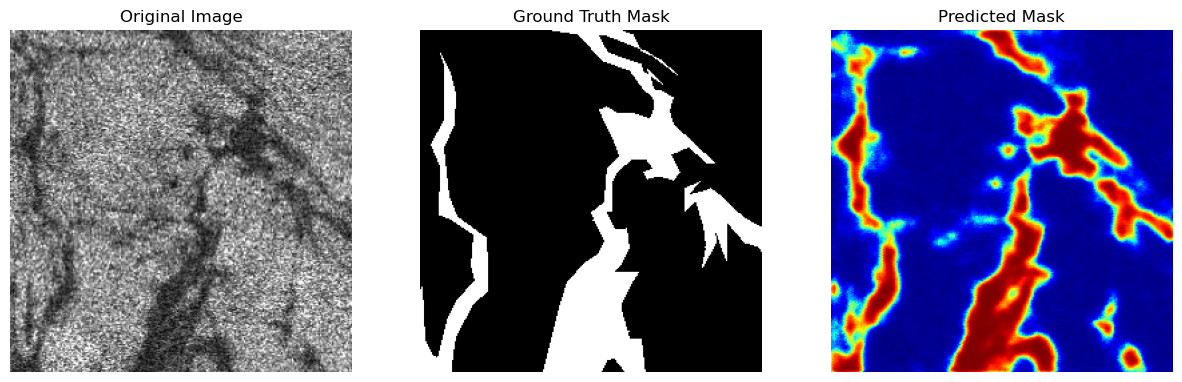

In [36]:
visualize_prediction(
    model,
    test_img_path,
    test_mask_path
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 715ms/step


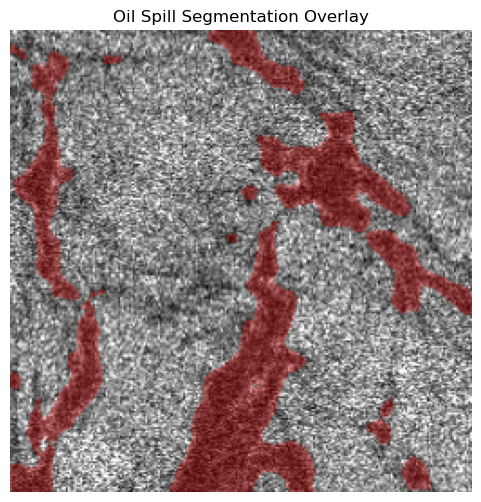

In [37]:
dashboard_visual(
    model,
    test_img_path
)

In [38]:
def predict_image(model, image_path, img_size=256):
    """
    Returns probability mask (float values between 0 and 1)
    Suitable for visualization and API response
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    img = img.astype(np.float32) / 255.0

    img = img[..., np.newaxis]
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img, verbose=0)[0, ..., 0]
    return pred

In [39]:
def predict_mask(model, image_path, img_size=256, threshold=0.5):
    """
    Returns binary segmentation mask (0 or 1)
    Suitable for deployment & downstream processing
    """
    pred = predict_image(model, image_path, img_size)
    return (pred > threshold).astype(np.uint8)

In [40]:
test_img = test_imgs[0]

prob_mask = predict_image(model, test_img)
bin_mask  = predict_mask(model, test_img)

print("Probability mask shape:", prob_mask.shape)
print("Binary mask unique values:", np.unique(bin_mask))

Probability mask shape: (256, 256)
Binary mask unique values: [0 1]
